# Exercice 7 - Apprentissage non supervisé

## Dataset : Pokemon with stats

URL : https://www.kaggle.com/datasets/abcsds/pokemon

On reprend le même dataset que pour l'exercice 6. Il regroupe les Pokémon des six premières générations avec leurs types et leurs statistiques de combat. Le fichier contient 800 lignes, car certains Pokémon apparaissent sous plusieurs formes, par exemple en Méga-Évolution.

Les six variables utilisées sont exprimées en points de statistique, sans unité physique :
- `HP` représente les points de vie du Pokémon ;
- `Attack` et `Defense` représentent ses capacités d'attaque et de défense physiques
- `Sp. Atk` et `Sp. Def` représentent ses capacités d'attaque et de défense spéciales
- `Speed` représente sa vitesse, qui intervient notamment dans l'ordre des actions pendant un combat.

## Objectif non supervisé

Dans cet exercice, on cherche à voir si des groupes de Pokémon apparaissent naturellement à partir des six statistiques de combat. On veut surtout savoir si ces groupes peuvent faire ressortir des profils stratégiques, par exemple des tanks, des attaquants physiques, des attaquants spéciaux ou des Pokémon rapides.

On utilise uniquement K-Means pour garder une méthode simple et facile à interpréter. Les types ne sont pas utilisés pour construire les clusters : on les regarde seulement après le clustering pour essayer de mieux comprendre les groupes obtenus.

## Imports et configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## Chargement des données

On télécharge directement le dataset depuis Kaggle avec `kagglehub`, puis on récupère le fichier CSV contenu dans le dossier téléchargé.

In [2]:
import kagglehub

dataset_dir = Path(kagglehub.dataset_download("abcsds/pokemon"))
csv_paths = sorted(dataset_dir.rglob("*.csv"))

if not csv_paths:
    raise FileNotFoundError("Aucun fichier CSV trouvé.")

data_path = csv_paths[0]
raw_df = pd.read_csv(data_path)
print(f"Dataset chargé depuis : {data_path}")
print(f"Nombre de lignes initial : {len(raw_df)}")
raw_df.head()

Dataset chargé depuis : /home/coco_ayano/.cache/kagglehub/datasets/abcsds/pokemon/versions/2/Pokemon.csv
Nombre de lignes initial : 800


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## Suppression des Méga-Évolutions et des formes alternatives

Le fichier contient 800 lignes, mais seulement 721 numéros de Pokédex différents. Cela vient surtout des Méga-Évolutions et des autres formes alternatives, qui gardent le même numéro que le Pokémon de base.

Comme dans l'exercice 6, on garde seulement la première ligne de chaque numéro de Pokédex. Un Pokémon n'est donc compté qu'une seule fois et les espèces qui ont plusieurs formes ne prennent pas plus de poids dans le clustering. Après ce nettoyage, il reste 721 lignes.

## Vérification des variables utilisées

On garde seulement les six statistiques de combat choisies au départ pour construire les clusters. Le nom et les types sont conservés à côté uniquement pour interpréter les résultats. Le numéro, la génération et le statut légendaire ne sont pas utilisés par K-Means.

In [3]:
initial_row_count = len(raw_df)
df = raw_df.drop_duplicates(subset="#", keep="first").reset_index(drop=True)

print(f"Nombre de lignes avant le nettoyage : {initial_row_count}")
print(f"Nombre de lignes après le nettoyage : {len(df)}")
print(f"Nombre de numéros de Pokédex uniques : {df['#'].nunique()}")

feature_columns = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
metadata_columns = ["Name", "Type 1", "Type 2"]

required_columns = feature_columns + metadata_columns
missing_columns = sorted(set(required_columns) - set(df.columns))
if missing_columns:
    raise ValueError(f"Colonnes manquantes dans le dataset : {missing_columns}")

data = df[metadata_columns + feature_columns].copy()
data.info()
display(data[feature_columns].describe().T)
data[feature_columns].isna().sum().to_frame("missing_values")

Nombre de lignes avant le nettoyage : 800
Nombre de lignes après le nettoyage : 721
Nombre de numéros de Pokédex uniques : 721
<class 'pandas.DataFrame'>
RangeIndex: 721 entries, 0 to 720
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Name     721 non-null    str  
 1   Type 1   721 non-null    str  
 2   Type 2   350 non-null    str  
 3   HP       721 non-null    int64
 4   Attack   721 non-null    int64
 5   Defense  721 non-null    int64
 6   Sp. Atk  721 non-null    int64
 7   Sp. Def  721 non-null    int64
 8   Speed    721 non-null    int64
dtypes: int64(6), str(3)
memory usage: 50.8 KB


,count,mean,std,min,25%,50%,75%,max
HP,721.0,68.380028,25.848272,1.0,50.0,65.0,80.0,255.0
Attack,721.0,75.124827,29.070335,5.0,54.0,75.0,95.0,165.0
Defense,721.0,70.697642,29.194941,5.0,50.0,65.0,85.0,230.0
Sp. Atk,721.0,68.848821,28.898590,10.0,45.0,65.0,90.0,154.0
Sp. Def,721.0,69.180305,26.899364,20.0,50.0,65.0,85.0,230.0
Speed,721.0,65.714286,27.277920,5.0,45.0,65.0,85.0,160.0


,missing_values
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0
Speed,0


## Analyse descriptive

Avant d'appliquer K-Means, on regarde la forme des variables et les liens possibles entre les statistiques.

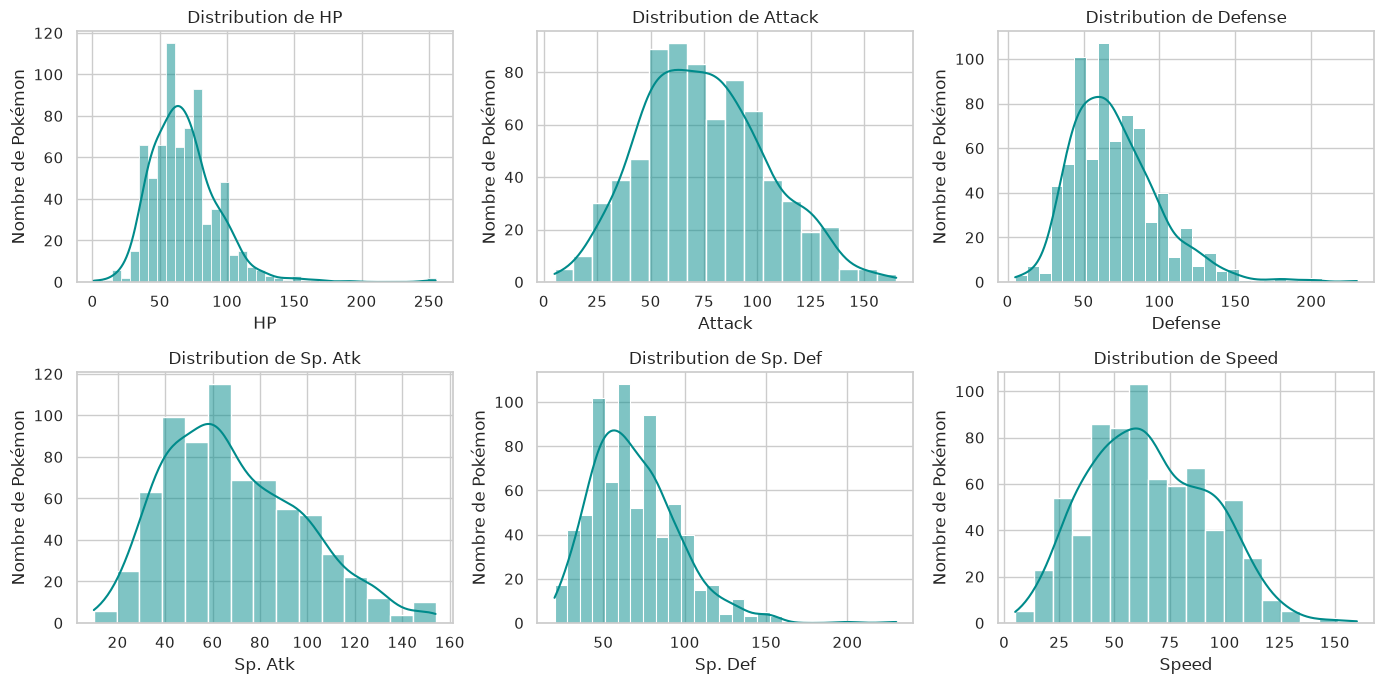

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, column in zip(axes.ravel(), feature_columns):
    sns.histplot(data=data, x=column, kde=True, ax=ax, color="darkcyan")
    ax.set_title(f"Distribution de {column}")
    ax.set_xlabel(f"{column}")
    ax.set_ylabel("Nombre de Pokémon")
plt.tight_layout()
plt.show()

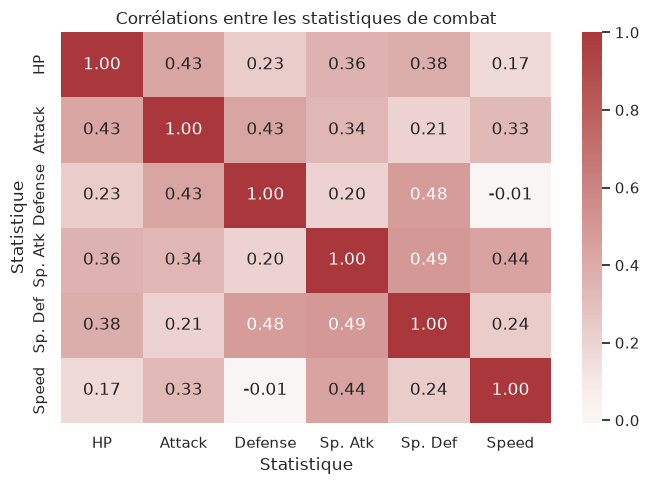

In [5]:
plt.figure(figsize=(7, 5))
sns.heatmap(data[feature_columns].corr(), annot=True, cmap="vlag", center=0, fmt=".2f")
plt.title("Corrélations entre les statistiques de combat")
plt.xlabel("Statistique")
plt.ylabel("Statistique")
plt.tight_layout()
plt.show()

### Distribution des statistiques

Comme dans l'exercice 6, on remarque quelques Pokémon avec des valeurs beaucoup plus élevées que la moyenne. Ce ne sont pas forcément des erreurs : certains Pokémon ont réellement des statistiques très particulières. On choisit donc de garder ces valeurs.

Le problème est qu'en utilisant directement ces valeurs, K-Means sépare surtout les Pokémon faibles des Pokémon puissants. Ce résultat peut être intéressant, mais il ne répond pas vraiment à notre objectif, qui est plutôt de faire apparaître des rôles de combat.

## Représentation des profils sans réduction de dimension

On n'utilise pas de PCA ici : K-Means travaille directement avec les six statistiques. On garde donc toutes les variables et les six dimensions.

Pour chaque Pokémon, on centre ses six statistiques autour de sa propre moyenne, puis on les divise par leur écart-type. On cherche ainsi à moins tenir compte de la puissance totale et à comparer plutôt la forme du profil. Par exemple, un Pokémon peut être considéré comme rapide par rapport à ses autres statistiques, même si son total général est assez faible.

Après cette transformation, une valeur positive représente une statistique plutôt forte pour le Pokémon et une valeur négative une statistique plutôt faible. On garde quand même le total original pour pouvoir comparer le niveau de puissance moyen des clusters à la fin.

K-Means utilise ici la distance euclidienne entre les six statistiques normalisées. Deux Pokémon sont donc proches si leurs profils ont une forme similaire, et pas seulement parce qu'ils ont un total similaire. Avec notre normalisation, cette distance est aussi liée à la corrélation entre les profils : plus deux profils évoluent de la même façon, plus ils seront proches. Cette distance nous paraît donc adaptée à ce qu'on cherche.

In [6]:
X_raw = data[feature_columns].astype(float)
X_column_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_raw),
    columns=feature_columns,
    index=X_raw.index,
)
row_means = X_raw.mean(axis=1)
row_stds = X_raw.std(axis=1).replace(0, 1)
X_profile = X_raw.sub(row_means, axis=0).div(row_stds, axis=0)

data["Stat total"] = X_raw.sum(axis=1)

def total_variance_explained(labels):
    totals = data["Stat total"]
    overall_mean = totals.mean()
    between_variance = sum(
        (labels == cluster).sum() * (totals[labels == cluster].mean() - overall_mean) ** 2
        for cluster in np.unique(labels)
    )
    total_variance = ((totals - overall_mean) ** 2).sum()
    return between_variance / total_variance

preprocessing_rows = []
for name, representation in {
    "Valeurs brutes": X_raw,
    "Standardisation par variable": X_column_scaled,
    "Normalisation par profil": X_profile,
}.items():
    comparison_model = KMeans(n_clusters=6, n_init=50, random_state=RANDOM_STATE)
    comparison_labels = comparison_model.fit_predict(representation)
    preprocessing_rows.append({
        "représentation": name,
        "silhouette": silhouette_score(representation, comparison_labels),
        "part_variance_total_expliquée": total_variance_explained(comparison_labels),
    })

preprocessing_comparison = pd.DataFrame(preprocessing_rows).set_index("représentation")
preprocessing_comparison.round(3)

,silhouette,part_variance_total_expliquée
représentation,,
Valeurs brutes,0.231,0.815
Standardisation par variable,0.232,0.813
Normalisation par profil,0.234,0.048


## Choix du nombre de clusters

On teste plusieurs nombres de clusters, de `k = 2` à `k = 10`. On regarde surtout le score de silhouette, mais aussi les scores de Calinski-Harabasz et de Davies-Bouldin. Pour Calinski-Harabasz, on préfère une valeur élevée, alors que pour Davies-Bouldin on préfère une valeur faible.

Ces scores permettent de voir si les groupes sont bien séparés, mais ils ne suffisent pas forcément à choisir le nombre de clusters le plus intéressant pour notre objectif.

In [7]:
score_rows = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_profile)
    score_rows.append({
        "k": k,
        "silhouette": silhouette_score(X_profile, labels),
        "calinski_harabasz": calinski_harabasz_score(X_profile, labels),
        "davies_bouldin": davies_bouldin_score(X_profile, labels),
    })

k_scores = pd.DataFrame(score_rows)
k_scores

,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.237344,234.492583,1.683339
1,3,0.234943,228.726143,1.501407
2,4,0.221957,207.487118,1.412808
3,5,0.224492,200.870937,1.320646
4,6,0.234150,194.829122,1.309975
5,7,0.239867,189.136143,1.237497
6,8,0.242886,185.084208,1.303863
7,9,0.255349,183.201953,1.258880
8,10,0.249595,179.559319,1.172663


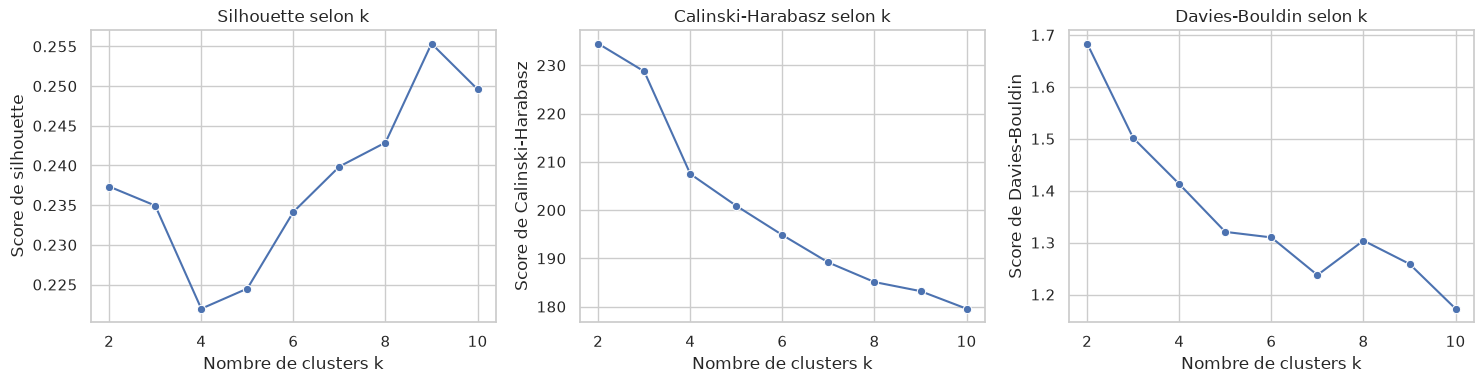

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.lineplot(data=k_scores, x="k", y="silhouette", marker="o", ax=axes[0])
sns.lineplot(data=k_scores, x="k", y="calinski_harabasz", marker="o", ax=axes[1])
sns.lineplot(data=k_scores, x="k", y="davies_bouldin", marker="o", ax=axes[2])
axes[0].set_title("Silhouette selon k")
axes[1].set_title("Calinski-Harabasz selon k")
axes[2].set_title("Davies-Bouldin selon k")
for ax in axes:
    ax.set_xlabel("Nombre de clusters k")
axes[0].set_ylabel("Score de silhouette")
axes[1].set_ylabel("Score de Calinski-Harabasz")
axes[2].set_ylabel("Score de Davies-Bouldin")
plt.tight_layout()
plt.show()

Les trois scores ne donnent pas le même choix : la silhouette est meilleure pour `k = 9`, Davies-Bouldin pour `k = 10` et Calinski-Harabasz pour `k = 2` parmi les valeurs testées. On n'a donc pas un nombre de clusters qui ressort clairement.

Nous choisissons finalement `k = 6` comme compromis. Le score de silhouette reste assez proche des meilleurs et, surtout, les six groupes obtenus sont assez différents pour être interprétés. Ce choix reste en partie subjectif : on ne prétend pas qu'il existe exactement six rôles naturels chez les Pokémon.

In [9]:
N_CLUSTERS = 6
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=50, random_state=RANDOM_STATE)
cluster_ids = kmeans.fit_predict(X_profile)

profile_centers = pd.DataFrame(kmeans.cluster_centers_, columns=feature_columns)
profile_centers.index.name = "cluster"
profile_centers.round(2)

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
cluster,,,,,,
0,1.39,-0.21,-0.27,-0.09,0.13,-0.94
1,-0.61,-0.31,-0.84,1.04,-0.27,0.98
2,-0.13,0.67,1.23,-0.72,-0.30,-0.77
3,0.09,1.48,-0.48,-0.05,-0.56,-0.48
4,-0.36,-0.49,0.22,0.44,0.91,-0.71
5,-0.31,0.42,-0.34,-0.81,-0.36,1.40


## Interprétation et nom des clusters

Pour comprendre les clusters, on regarde leur centroïde, c'est-à-dire le profil moyen du groupe après transformation. On donne ensuite un nom à chaque groupe selon les statistiques qui ressortent le plus. Ce sont seulement des noms qu'on utilise pour rendre les résultats plus faciles à lire, pas des rôles officiels.

In [10]:
def infer_role(center):
    ranking = center.sort_values(ascending=False).index.tolist()
    strongest = ranking[0]
    two_strongest = set(ranking[:2])

    if "Speed" in two_strongest and "Sp. Atk" in two_strongest:
        return "Sweeper spécial rapide"
    if "Speed" in two_strongest and "Attack" in two_strongest:
        return "Sweeper physique rapide"
    if strongest == "HP":
        return "Tank à hauts PV"
    if strongest == "Defense":
        return "Tank physique"
    if strongest == "Sp. Def":
        return "Tank spécial"
    if strongest == "Speed":
        offensive_stat = "Attack" if center["Attack"] >= center["Sp. Atk"] else "Sp. Atk"
        return "Sweeper physique rapide" if offensive_stat == "Attack" else "Sweeper spécial rapide"
    if strongest == "Attack":
        return "Attaquant physique"
    return "Attaquant spécial"


role_by_cluster = {cluster: infer_role(center) for cluster, center in profile_centers.iterrows()}
role_by_cluster

{0: 'Tank à hauts PV',
 1: 'Sweeper spécial rapide',
 2: 'Tank physique',
 3: 'Attaquant physique',
 4: 'Tank spécial',
 5: 'Sweeper physique rapide'}

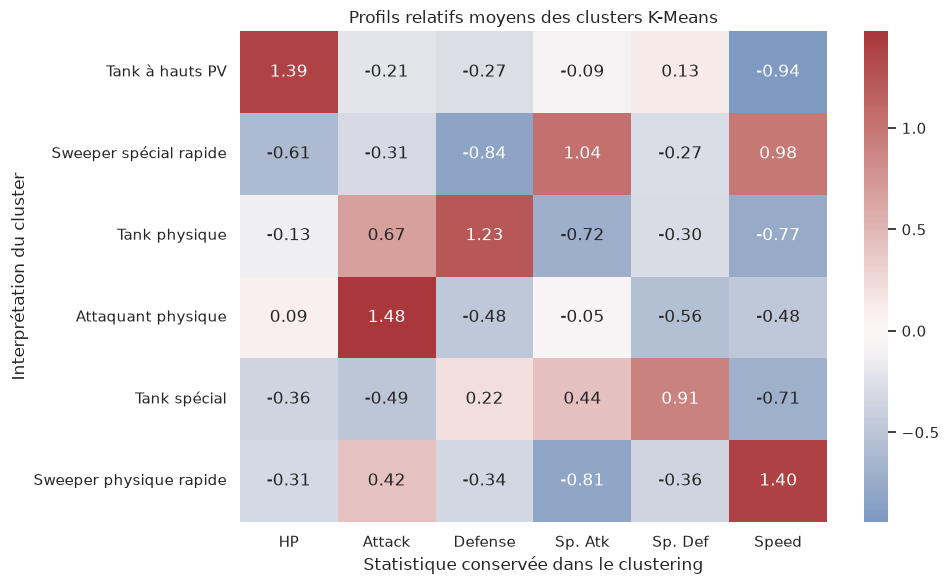

In [11]:
analysis_df = data.copy()
analysis_df["cluster"] = cluster_ids
analysis_df["role"] = analysis_df["cluster"].map(role_by_cluster)

role_order = [role_by_cluster[i] for i in sorted(role_by_cluster)]
center_by_role = profile_centers.rename(index=role_by_cluster).loc[role_order]

plt.figure(figsize=(10, 6))
sns.heatmap(center_by_role, annot=True, cmap="vlag", center=0, fmt=".2f")
plt.title("Profils relatifs moyens des clusters K-Means")
plt.xlabel("Statistique conservée dans le clustering")
plt.ylabel("Interprétation du cluster")
plt.tight_layout()
plt.show()

La heatmap montre directement les six statistiques des centroïdes, sans projection en deux dimensions. Une case rouge indique une statistique plutôt forte dans le profil et une case bleue une statistique plutôt faible.

In [12]:
cluster_summary = (
    analysis_df.groupby(["cluster", "role"])
    .agg(
        effectif=("Name", "size"),
        total_moyen=("Stat total", "mean"),
        total_median=("Stat total", "median"),
    )
    .reset_index()
)
cluster_summary[["total_moyen", "total_median"]] = cluster_summary[["total_moyen", "total_median"]].round(1)
cluster_summary

,cluster,role,effectif,total_moyen,total_median
0,0,Tank à hauts PV,79,397.0,415.0
1,1,Sweeper spécial rapide,116,436.6,448.0
2,2,Tank physique,129,408.2,410.0
3,3,Attaquant physique,128,434.4,452.0
4,4,Tank spécial,153,441.4,465.0
5,5,Sweeper physique rapide,116,375.3,381.0


In [13]:
raw_profiles = analysis_df.groupby("role")[feature_columns].mean().loc[role_order].round(1)
raw_profiles

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
role,,,,,,
Tank à hauts PV,101.6,60.9,58.1,63.1,68.2,45.2
Sweeper spécial rapide,61.1,67.0,56.6,92.7,67.9,91.3
Tank physique,63.3,84.3,99.3,51.5,60.9,48.8
Attaquant physique,74.1,101.1,63.6,71.0,61.2,63.4
Tank spécial,64.9,62.7,80.5,81.7,93.8,57.6
Sweeper physique rapide,56.9,70.5,56.4,48.7,56.7,86.1


## Pokémon représentatifs

Pour chaque cluster, on affiche les cinq Pokémon les plus proches du centroïde dans l'espace à six dimensions. Ce sont les exemples qui ressemblent le plus au profil moyen du groupe.

In [14]:
distances = kmeans.transform(X_profile)
analysis_df["distance_to_center"] = distances[np.arange(len(data)), cluster_ids]

representatives = (
    analysis_df.sort_values(["cluster", "distance_to_center"])
    .groupby("cluster", group_keys=False)
    .head(5)[["cluster", "role", "Name", "Type 1", "Type 2", "Stat total", "distance_to_center"]]
)
representatives.round({"distance_to_center": 2})

,cluster,role,Name,Type 1,Type 2,Stat total,distance_to_center
130,0,Tank à hauts PV,Lapras,Water,Ice,535.0,0.54
421,0,Tank à hauts PV,Shellos,Water,NaN,325.0,0.75
339,0,Tank à hauts PV,Whiscash,Water,Ground,468.0,0.78
205,0,Tank à hauts PV,Dunsparce,Normal,NaN,415.0,0.79
698,0,Tank à hauts PV,Aurorus,Rock,Ice,521.0,0.85
4,1,Sweeper spécial rapide,Charmeleon,Fire,NaN,405.0,0.48
155,1,Sweeper spécial rapide,Quilava,Fire,NaN,405.0,0.48
5,1,Sweeper spécial rapide,Charizard,Fire,Flying,534.0,0.61
156,1,Sweeper spécial rapide,Typhlosion,Fire,NaN,534.0,0.61
308,1,Sweeper spécial rapide,Electrike,Electric,NaN,295.0,0.62


## Relation descriptive avec les types

Les types ne sont pas utilisés pour construire les clusters. On les regarde seulement après coup pour voir si certains types apparaissent plus souvent dans certains profils.

Pour éviter de simplement retrouver les types les plus fréquents du dataset, on calcule un indice d'enrichissement. On divise la proportion d'un type dans un cluster par sa proportion dans tout le dataset. Une valeur supérieure à `1` veut donc dire que ce type est plus présent que d'habitude dans le cluster.

Il faut quand même faire attention aux petits effectifs : un enrichissement peut paraître très élevé alors qu'il ne concerne qu'un ou deux Pokémon. On garde donc seulement les types présents au moins dix fois dans le dataset et au moins trois fois dans le cluster. On affiche aussi les effectifs dans le tableau.

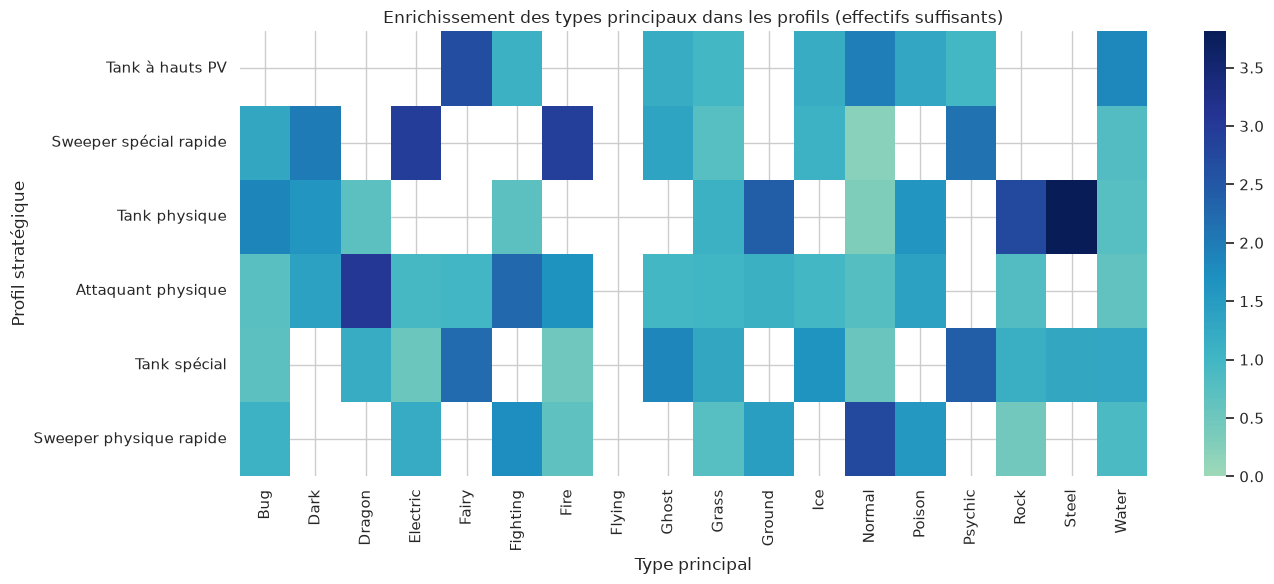

,role,Type 1,enrichment,effectif_cluster,effectif_total
56,Attaquant physique,Dragon,3.05,13,24
59,Attaquant physique,Fighting,2.25,10,25
60,Attaquant physique,Fire,1.68,14,47
102,Sweeper physique rapide,Normal,2.74,41,93
95,Sweeper physique rapide,Fighting,1.74,7,25
103,Sweeper physique rapide,Poison,1.55,7,28
21,Sweeper spécial rapide,Electric,2.94,17,36
24,Sweeper spécial rapide,Fire,2.91,22,47
32,Sweeper spécial rapide,Psychic,2.12,16,47
52,Tank physique,Steel,3.81,15,22


In [15]:
global_type_counts = analysis_df["Type 1"].value_counts()
global_type_frequency = global_type_counts / len(analysis_df)
cluster_type_counts = pd.crosstab(analysis_df["role"], analysis_df["Type 1"]).loc[role_order]
cluster_type_frequency = cluster_type_counts.div(cluster_type_counts.sum(axis=1), axis=0)
type_enrichment = cluster_type_frequency.div(global_type_frequency, axis=1).loc[role_order]
reliable_associations = cluster_type_counts.ge(3) & global_type_counts.ge(10)
displayed_enrichment = type_enrichment.where(reliable_associations)

plt.figure(figsize=(14, 6))
sns.heatmap(displayed_enrichment, cmap="YlGnBu", center=1, vmin=0)
plt.title("Enrichissement des types principaux dans les profils (effectifs suffisants)")
plt.xlabel("Type principal")
plt.ylabel("Profil stratégique")
plt.tight_layout()
plt.show()

top_enrichments = (
    displayed_enrichment.stack()
    .rename("enrichment")
    .reset_index()
    .assign(
        effectif_cluster=lambda frame: [
            cluster_type_counts.loc[role, pokemon_type]
            for role, pokemon_type in zip(frame["role"], frame["Type 1"])
        ],
        effectif_total=lambda frame: frame["Type 1"].map(global_type_counts),
    )
    .sort_values(["role", "enrichment"], ascending=[True, False])
    .groupby("role", group_keys=False)
    .head(3)
)
top_enrichments.round(2)

## Évaluation et stabilité

In [16]:
final_scores = pd.Series({
    "silhouette": silhouette_score(X_profile, cluster_ids),
    "calinski_harabasz": calinski_harabasz_score(X_profile, cluster_ids),
    "davies_bouldin": davies_bouldin_score(X_profile, cluster_ids),
})

initialization_labels = [
    KMeans(n_clusters=N_CLUSTERS, n_init=20, random_state=seed).fit_predict(X_profile)
    for seed in range(10)
]
initialization_ari = [
    adjusted_rand_score(initialization_labels[i], initialization_labels[j])
    for i in range(len(initialization_labels))
    for j in range(i)
]

rng = np.random.default_rng(RANDOM_STATE)
subsample_labels = []
for seed in range(10):
    sample_indices = rng.choice(len(X_profile), size=int(0.8 * len(X_profile)), replace=False)
    subsample_model = KMeans(n_clusters=N_CLUSTERS, n_init=50, random_state=seed)
    subsample_model.fit(X_profile.iloc[sample_indices])
    subsample_labels.append(subsample_model.predict(X_profile))

subsample_ari = [
    adjusted_rand_score(subsample_labels[i], subsample_labels[j])
    for i in range(len(subsample_labels))
    for j in range(i)
]

evaluation = pd.Series({
    **final_scores.to_dict(),
    "ARI_initialisations_moyen": np.mean(initialization_ari),
    "ARI_initialisations_minimum": np.min(initialization_ari),
    "ARI_sous_echantillons_moyen": np.mean(subsample_ari),
    "ARI_sous_echantillons_minimum": np.min(subsample_ari),
})
evaluation.round(3)

silhouette                         0.234
calinski_harabasz                194.829
davies_bouldin                     1.310
ARI_initialisations_moyen          0.867
ARI_initialisations_minimum        0.514
ARI_sous_echantillons_moyen        0.627
ARI_sous_echantillons_minimum      0.447
dtype: float64

Le score de silhouette donne une idée de la séparation entre les groupes. Comme il reste assez moyen, les rôles trouvés ressemblent plus à des tendances qu'à des catégories parfaitement séparées.

On regarde aussi si les clusters restent stables avec l'ARI. D'abord, on relance K-Means avec plusieurs initialisations sur toutes les données. Ensuite, on entraîne le modèle sur plusieurs sous-échantillons contenant 80 % des Pokémon, puis on compare les groupes prédits sur le dataset complet. Ce deuxième test permet de voir si le résultat change quand on enlève une partie des Pokémon. Un ARI proche de `1` correspond à des regroupements très similaires.

Entre les différentes initialisations, l'ARI vaut environ `0.87` en moyenne, mais il descend jusqu'à `0.51`. Avec les sous-échantillons, la moyenne tombe à `0.63` et le minimum à `0.45`. On retrouve donc assez souvent les grandes familles de profils, mais certains Pokémon peuvent changer de groupe selon les données utilisées ou l'initialisation.

## Discussion des résultats

La comparaison des prétraitements montre que les clusters obtenus avec les valeurs brutes sont surtout liés à la puissance totale : ils expliquent environ `81.5 %` de sa variance. La standardisation classique par variable ne change presque rien ici (`81.3 %`). Avec la normalisation par Pokémon, cette proportion tombe à environ `4.8 %`. Nous gardons donc cette méthode, puisqu'elle correspond mieux à notre idée de comparer la forme des profils plutôt que leur puissance générale.

Avec six clusters, on obtient des groupes qui font penser à plusieurs rôles de combat : tanks avec beaucoup de points de vie, tanks physiques ou spéciaux, attaquants physiques et sweepers rapides physiques ou spéciaux. Les Pokémon les plus proches des centroïdes correspondent plutôt bien à ces descriptions, même si tous les Pokémon d'un groupe ne suivent pas exactement le profil annoncé.

Le score de silhouette vaut environ `0.23`, donc les groupes ne sont pas très nettement séparés. La stabilité est plutôt bonne entre les initialisations (`ARI` moyen de `0.87`), mais elle devient plus moyenne avec les sous-échantillons (`0.63`). On considère donc les rôles comme des tendances qui aident à décrire les données, pas comme des catégories exactes.

Au final, on considère que l'objectif est plutôt atteint : K-Means fait ressortir plusieurs familles de profils qu'on peut rapprocher de rôles de combat. Les noms des clusters restent cependant notre interprétation des statistiques moyennes et ne donnent pas forcément le rôle exact de chaque Pokémon.